In [1]:
import torch
import torch.nn as nn
import torchvision.datasets as dsets
import torchvision.transforms as transforms

In [2]:
batch_size = 32
train_dataset = dsets.MNIST(root='.',
                            train=True,
                            transform=transforms.ToTensor(),
                            download=True)

test_dataset = dsets.MNIST(root='.',
                           train=False, 
                           transform=transforms.ToTensor(),
                           download=True)


train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

In [3]:
print("* Размер train\n [количество_примеров, высота_картинки, ширина_картинки]: \n", train_dataset.train_data.shape)
print("\n* Размер test\n [количество_примеров, высота_картинки, ширина_картинки]: \n", test_dataset.test_data.shape)
print("\nМетки классов в датасете: ", train_dataset.train_labels.unique())

* Размер train
 [количество_примеров, высота_картинки, ширина_картинки]: 
 torch.Size([60000, 28, 28])

* Размер test
 [количество_примеров, высота_картинки, ширина_картинки]: 
 torch.Size([10000, 28, 28])

Метки классов в датасете:  tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


C:\Users\Nikita\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\datasets\mnist.py:75: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
C:\Users\Nikita\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\datasets\mnist.py:80: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
C:\Users\Nikita\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\datasets\mnist.py:65: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


C:\Users\Nikita\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\datasets\mnist.py:75: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


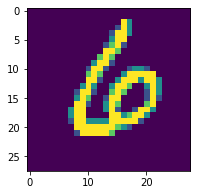

In [4]:
import numpy as np
from matplotlib import pyplot as plt

fig=plt.figure(figsize=(8, 3))

idx = np.random.choice(150)
img = train_dataset.train_data[idx]

plt.imshow(img)
plt.show()

In [5]:
class LogisticRegression(nn.Module):
    def __init__(self, input_size, num_classes):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        logits = self.linear(x)
        return logits

In [6]:
# Задаем гиперпараметры
input_size = 784 # 28*28 -- мы вытянули в линию все пиксели картинки
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 0.001

In [7]:
# Создаем модель
model = LogisticRegression(input_size=input_size, num_classes=num_classes)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):

        images = images.view(-1, 28*28)
        outputs = model.forward(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 100 == 0:
            print ('epoch:%d/%d, %d Loss: %.4f' % (epoch, num_epochs,i +1 , loss.item()))

epoch:0/5, 100 Loss: 0.7980
epoch:0/5, 200 Loss: 0.7801
epoch:0/5, 300 Loss: 0.5545
epoch:0/5, 400 Loss: 0.3340
epoch:0/5, 500 Loss: 0.3338
epoch:0/5, 600 Loss: 0.4613
epoch:0/5, 700 Loss: 0.4116
epoch:0/5, 800 Loss: 0.4179
epoch:0/5, 900 Loss: 0.3499
epoch:0/5, 1000 Loss: 0.3592
epoch:0/5, 1100 Loss: 0.2947
epoch:0/5, 1200 Loss: 0.1693
epoch:0/5, 1300 Loss: 0.3964
epoch:0/5, 1400 Loss: 0.3462
epoch:0/5, 1500 Loss: 0.3203
epoch:0/5, 1600 Loss: 0.1232
epoch:0/5, 1700 Loss: 0.0930
epoch:0/5, 1800 Loss: 0.6451
epoch:1/5, 100 Loss: 0.1984
epoch:1/5, 200 Loss: 0.3342
epoch:1/5, 300 Loss: 0.1937
epoch:1/5, 400 Loss: 0.4906
epoch:1/5, 500 Loss: 0.3855
epoch:1/5, 600 Loss: 0.3380
epoch:1/5, 700 Loss: 0.4015
epoch:1/5, 800 Loss: 0.3664
epoch:1/5, 900 Loss: 0.6162
epoch:1/5, 1000 Loss: 0.3097
epoch:1/5, 1100 Loss: 0.2097
epoch:1/5, 1200 Loss: 0.1855
epoch:1/5, 1300 Loss: 0.2699
epoch:1/5, 1400 Loss: 0.2207
epoch:1/5, 1500 Loss: 0.2387
epoch:1/5, 1600 Loss: 0.2949
epoch:1/5, 1700 Loss: 0.2393
epo

## Визуализация весов

In [10]:
W = model.parameters().__next__().detach().numpy()
W.shape

(10, 784)

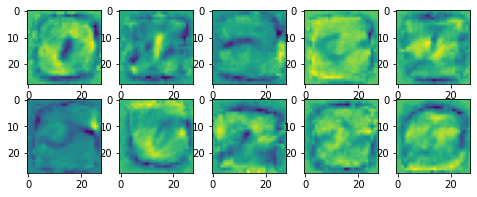

In [11]:
fig=plt.figure(figsize=(8, 3))
columns = 5
rows = 2
for i in range(1, columns*rows +1):
    img = W[i-1].reshape((28, 28))
    fig.add_subplot(rows, columns, i)
    plt.imshow(img)
plt.show()

In [12]:
from sklearn.metrics import roc_auc_score

y_pred = np.array([0 for _ in range(num_classes)])
y_true = np.array([])
for images, labels in test_loader:
    images = images.view(-1, 28*28)
    outputs = model(images)
    y_true = np.append(y_true, labels.numpy())
    s = nn.Softmax()
    y_cur = s(outputs).detach().numpy()
    y_pred = np.vstack((y_pred, y_cur))

y_pred = y_pred[1:]

roc_auc_score(y_true, y_pred, multi_class='ovr')

C:\Users\Nikita\AppData\Local\Temp\ipykernel_17328\1352141230.py:10: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  y_cur = s(outputs).detach().numpy()


0.9941125167836065